# Descriptive Statistics: Thống kê mô tả
**STAT3013 | TrainHyp**

| Mục | Chi tiết |
|-----|---------|
| Input  | `data_features.csv` (từ NB01) |
| Output | `descriptive_stats.csv`, các biểu đồ phân phối (fig1 đến fig5) |

## Lý do khoa học cho Thống kê mô tả
> **Thống kê mô tả không đưa ra kết luận nhân quả, nhưng là nền tảng bắt buộc để hiểu rõ bản chất dữ liệu trước khi kiểm định.**

Vai trò của bước này:
- **Nhận diện xu hướng và phân phối:** Giúp chúng ta nhìn thấy hình dạng thực tế của dữ liệu (ví dụ: điểm số hedges_g trung bình là bao nhiêu, dữ liệu có bị lệch không).
- **Phát hiện ngoại lệ (Outliers):** Thông qua các biểu đồ Boxplot, ta có thể tìm ra các trường hợp tập luyện mang lại kết quả quá cao hoặc quá thấp so với phần lớn dữ liệu.
- **Định hướng giả thuyết:** Các biểu đồ phân tán (Scatter plot) giữa khối lượng tập luyện và sự phát triển cơ bắp cung cấp những manh mối trực quan đầu tiên để thiết lập các phép kiểm định thống kê ở bước sau.

In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
# [MỤC ĐÍCH]: Thiết lập thẩm mỹ (Global Style) cho toàn bộ báo cáo và nạp dữ liệu.
# [KỸ THUẬT]: Loại bỏ Spines (đường khung) phía trên/phải để giảm nhiễu thị giác (Data-ink ratio), tập trung sự chú ý vào xu hướng của biểu đồ.
plt.rcParams.update({
    "figure.dpi": 150,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11
})
COLORS = {"Low":"#E74C3C", "Moderate":"#F39C12", "High":"#2ECC71"}

df = pd.read_csv("/content/gdrive/MyDrive/STAT3013/Dataset/data_cleaned.csv")

# [TRUỶỀN TẢI LOGIC]: Định nghĩa thứ tự thứ bậc (Ordinal) cho Volume và Hypertrophy Class.
# Việc này đảm bảo khi vẽ biểu đồ hoặc tính tương quan, các nhóm sẽ hiển thị theo đúng tiến trình sinh lý (Thấp -> Cao).
df["volume_category"] = pd.Categorical(df["volume_category"],
    categories=["Low","Moderate","High"], ordered=True)
df["hyp_class"] = pd.Categorical(df["hyp_class"],
    categories=["Low","Medium","High"], ordered=True)

print(f"Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

# Kiểm soát nhanh chất lượng dữ liệu (Data Audit) thông qua các đại lượng thống kê mô tả then chốt.
df[["hedges_g","sets.week.all","frequency.direct","weeks","age"]].describe().round(3)

Loaded: 198 rows, 36 columns


,hedges_g,sets.week.all,frequency.direct,weeks,age
count,198.000,198.000,198.000,198.000,198.000
mean,0.429,15.504,2.112,9.990,26.064
std,0.370,10.894,1.190,3.613,5.847
min,-0.208,0.000,0.000,6.000,19.500
25%,0.145,6.947,1.000,8.000,22.500
50%,0.360,12.000,2.000,8.500,23.800
75%,0.615,24.000,3.000,11.750,26.700
max,2.259,48.000,6.000,24.330,45.400


## 1. Bảng thống kê mô tả đầy đủ

In [4]:
# [MỤC ĐÍCH]: Khởi tạo bộ từ điển biến số (Mapping Dictionary) để chuẩn hóa tên gọi cho báo cáo cuối cùng.
# [KỸ THUẬT]: Tách biệt biến mục tiêu (Hedges' g) và các biến độc lập (Volume, Intensity, Demographics) giúp người đọc dễ dàng theo dõi logic phân tích.
KEY_VARS = {
    "hedges_g":                "Hedges g (TARGET)",
    "sets.week.all":           "Sets/Week (all)",
    "sets.week.direct":        "Sets/Week (direct)",
    "frequency.direct":        "Frequency (direct)",
    "sessions.per.week":       "Sessions/Week",
    "reps.week.all":           "Reps/Week",
    "rep.range.all":           "Rep Range",
    "interset.rest.min.all":   "Rest (min)",
    "percentage.failure.all":  "% Failure",
    "weeks":                   "Duration (weeks)",
    "age":                     "Age",
    "sex.male":                "% Male",
    "body.mass":               "Body Mass (kg)",
    "years.exp":               "Years Experience",
}

rows = []
# [XỬ LÝ DỮ LIỆU]: Tính toán các đại lượng thống kê mô tả (Descriptive Statistics) chuyên sâu.
# Việc bao gồm Median và Quartiles giúp đánh giá độ lệch (skewness) của dữ liệu y sinh, vốn thường không phân phối chuẩn.
for col, label in KEY_VARS.items():
    s = df[col].dropna()
    rows.append({
        "Variable":   label,
        "N":          len(s),
        "Mean":       round(s.mean(), 3),
        "Median":     round(s.median(), 3),
        "SD":         round(s.std(), 3),
        "Min":        round(s.min(), 3),
        "Max":        round(s.max(), 3),
        "Q1":         round(s.quantile(0.25), 3),
        "Q3":         round(s.quantile(0.75), 3),
    })

# Chuyển đổi sang DataFrame và lưu trữ phục vụ việc chèn bảng vào báo cáo/luận văn mà không cần format lại thủ công.
desc_table = pd.DataFrame(rows)
desc_table.to_csv("/content/gdrive/MyDrive/STAT3013/Dataset/descriptive_stats.csv", index=False)
print("Saved: descriptive_stats.csv")
desc_table

Saved: descriptive_stats.csv


,Variable,N,Mean,Median,SD,Min,Max,Q1,Q3
0,Hedges g (TARGET),198,0.429,0.360,0.370,-0.208,2.259,0.145,0.615
1,Sets/Week (all),198,15.504,12.000,10.894,0.000,48.000,6.947,24.000
2,Sets/Week (direct),198,10.585,9.000,8.903,0.000,45.000,4.742,14.750
3,Frequency (direct),198,2.112,2.000,1.190,0.000,6.000,1.000,3.000
4,Sessions/Week,198,3.031,3.000,1.441,0.000,8.000,2.000,4.000
5,Reps/Week,198,151.250,135.135,107.730,0.000,480.000,60.000,216.000
6,Rep Range,198,10.503,10.000,1.847,7.000,21.660,9.600,11.100
7,Rest (min),198,1.837,2.000,0.657,1.000,4.111,1.500,2.000
8,% Failure,198,83.584,100.000,34.436,0.000,100.000,100.000,100.000
9,Duration (weeks),198,9.990,8.500,3.613,6.000,24.330,8.000,11.750


## 2. Phân phối theo train.status và volume_category

In [5]:
# [MỤC ĐÍCH]: Kiểm toán phân phối dữ liệu (Data Distribution Audit) trên các biến phân loại chính.
# [ĐIỂM CHẠM HỌC THUẬT]: Đánh giá độ cân bằng của các nhóm mẫu (Class Balance). Việc hiểu rõ số lượng nghiên cứu trong từng nhóm (ví dụ: Nutrition hay Hyp Class) giúp xác định giới hạn của các kiểm định thống kê phía sau.

print("=== Train Status ===")
print(df["train.status"].value_counts())

# Kiểm tra phân phối theo Volume: Đảm bảo thứ tự Low -> High được giữ nguyên để soi chiếu logic Dose-response.
print("\n=== Volume Category ===")
print(df["volume_category"].value_counts().sort_index())

# Theo dõi phân phối biến mục tiêu (Hypertrophy Class) để nhận diện các nhóm thiểu số (Under-represented groups).
print("\n=== Hyp Class ===")
print(df["hyp_class"].value_counts().sort_index())

print("\n=== Nutrition ===")
print(df["nutrition_category"].value_counts())

=== Train Status ===
train.status
trained      117
untrained     81
Name: count, dtype: int64

=== Volume Category ===
volume_category
Low         48
Moderate    61
High        89
Name: count, dtype: int64

=== Hyp Class ===
hyp_class
Low        60
Medium    112
High       26
Name: count, dtype: int64

=== Nutrition ===
nutrition_category
Surplus    6
Deficit    4
Name: count, dtype: int64


## 3. Figure 1 — Histogram phân phối Hedges g

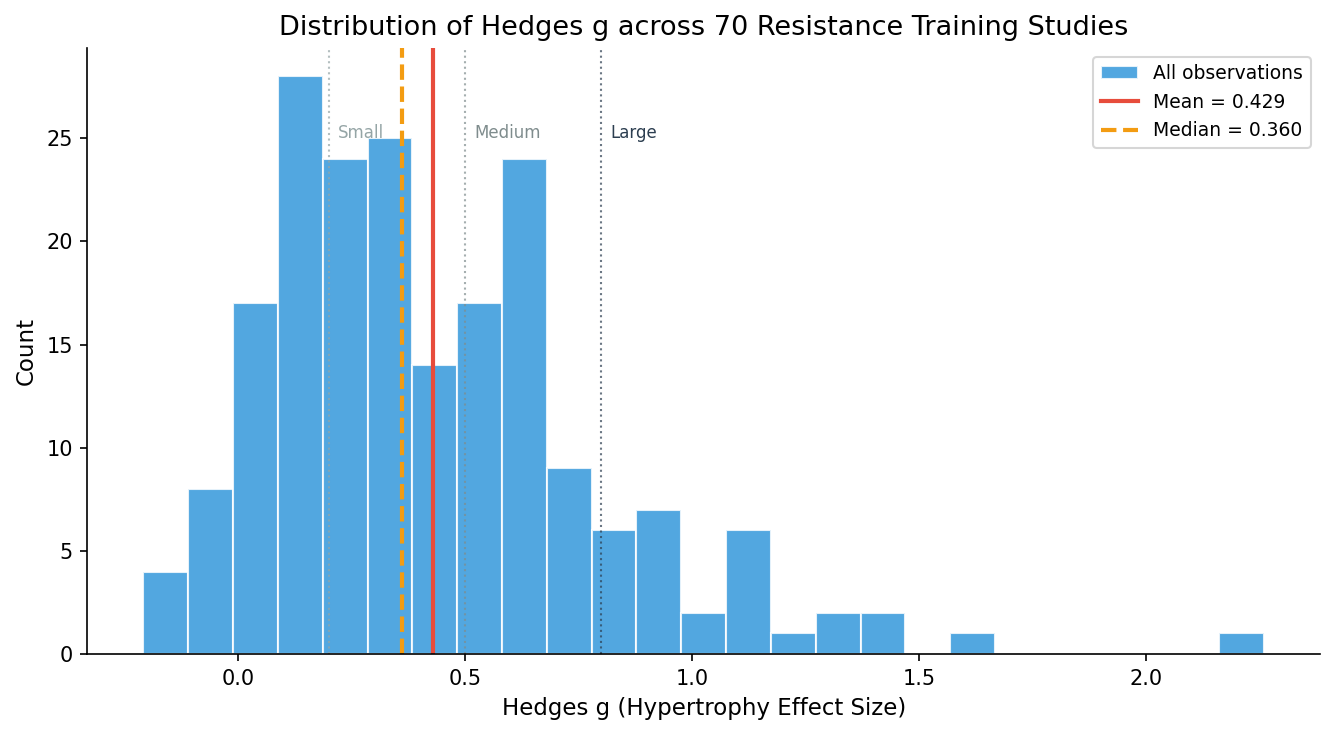

In [6]:
# [MỤC ĐÍCH]: Kiểm tra hình dạng phân phối của biến mục tiêu (Hedges' g).
# [ĐIỂM CHẠM HỌC THUẬT]: Đánh giá độ lệch (Skewness) giữa Mean và Median để xác định tính chuẩn của dữ liệu.
fig, ax = plt.subplots(figsize=(9,5))

ax.hist(df["hedges_g"], bins=25, color="#3498DB", edgecolor="white",
        alpha=0.85, label="All observations")

# Trực quan hóa xu hướng tập trung (Central Tendency).
ax.axvline(df["hedges_g"].mean(),   color="#E74C3C", lw=2, ls="-",  label=f"Mean = {df['hedges_g'].mean():.3f}")
ax.axvline(df["hedges_g"].median(), color="#F39C12", lw=2, ls="--", label=f"Median = {df['hedges_g'].median():.3f}")

# [KỸ THUẬT]: Chèn các ngưỡng tham chiếu (Benchmarks) của Cohen để phân loại mức độ hiệu quả (Small/Medium/Large).
# Việc này giúp hội đồng có ngay hệ quy chiếu để đánh giá tính thực tiễn của dữ liệu y sinh.
for g_val, lbl, c in [(0.2,"Small","#95A5A6"), (0.5,"Medium","#7F8C8D"), (0.8,"Large","#2C3E50")]:
    ax.axvline(g_val, color=c, lw=1, ls=":", alpha=0.7)
    ax.text(g_val+0.02, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1]>0 else 10,
            lbl, fontsize=8, color=c)

ax.set_xlabel("Hedges g (Hypertrophy Effect Size)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Hedges g across 70 Resistance Training Studies")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig1_hedges_g_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## 4. Figure 2 — Boxplot Hedges g theo Volume Category

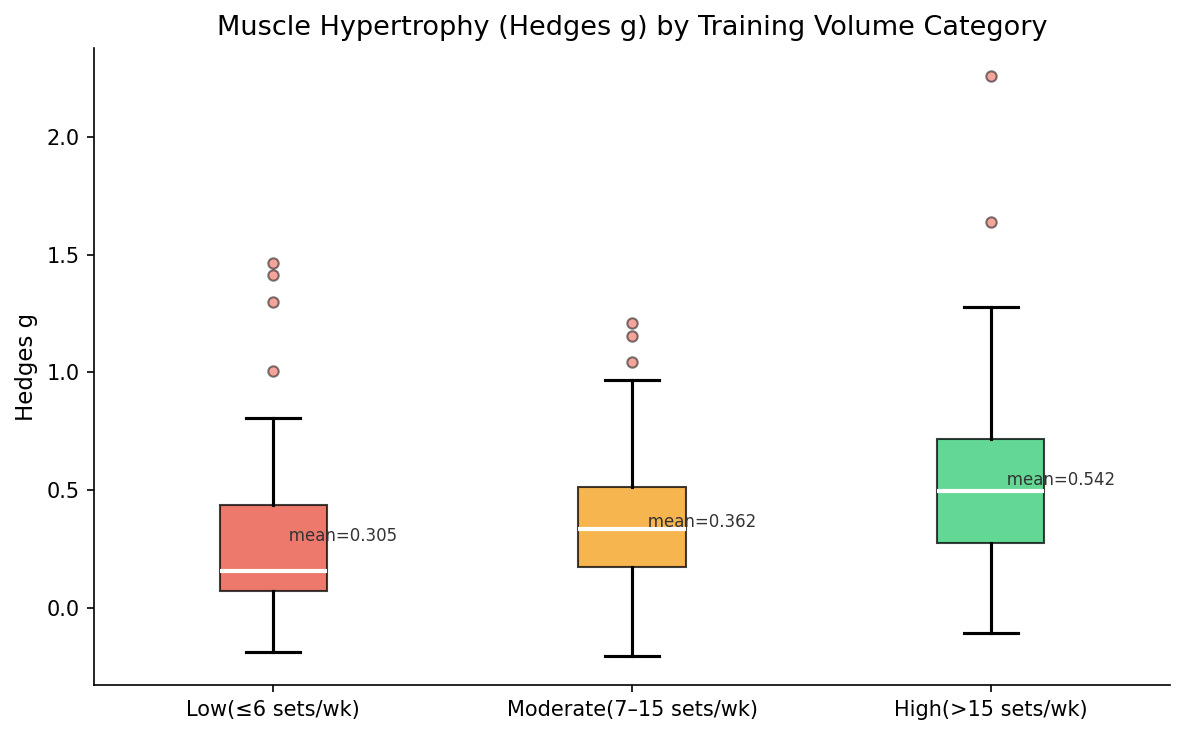

In [7]:
# [MỤC ĐÍCH]: So sánh sự phân tán và mức độ hiệu quả (Hypertrophy) giữa 3 ngưỡng Volume.
# [ĐIỂM CHẠM HỌC THUẬT]: Sử dụng Boxplot để nhận diện Outliers và độ biến thiên (Interquartile Range).
# Việc này giúp xác định xem High Volume mang lại kết quả tốt ổn định hay chỉ do một vài cá nhân đột biến (outliers) kéo lên.
fig, ax = plt.subplots(figsize=(8,5))

groups = [df[df["volume_category"]==g]["hedges_g"].dropna() for g in ["Low","Moderate","High"]]
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2),
                whiskerprops=dict(lw=1.5),
                capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markersize=5, alpha=0.5))

# [THẨM MỸ]: Áp dụng bảng màu phân cấp (Red -> Yellow -> Green) để ám chỉ sự tăng tiến về khối lượng tập.
for patch, color in zip(bp["boxes"], ["#E74C3C","#F39C12","#2ECC71"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# [KỸ THUẬT]: Chèn số liệu Mean trực tiếp vào biểu đồ để hỗ trợ việc so sánh nhanh độ dốc của hiệu ứng Dose-response mà không cần đối chiếu bảng phụ.
means = [g.mean() for g in groups]
for i, m in enumerate(means):
    ax.text(i+1, m, f"   mean={m:.3f}", va="center", fontsize=8, color="#333333")

ax.set_xticklabels(["Low(≤6 sets/wk)","Moderate(7–15 sets/wk)","High(>15 sets/wk)"])
ax.set_ylabel("Hedges g")
ax.set_title("Muscle Hypertrophy (Hedges g) by Training Volume Category")

plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig2_boxplot_volume_category.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Figure 3 — Boxplot Hedges g theo Train Status

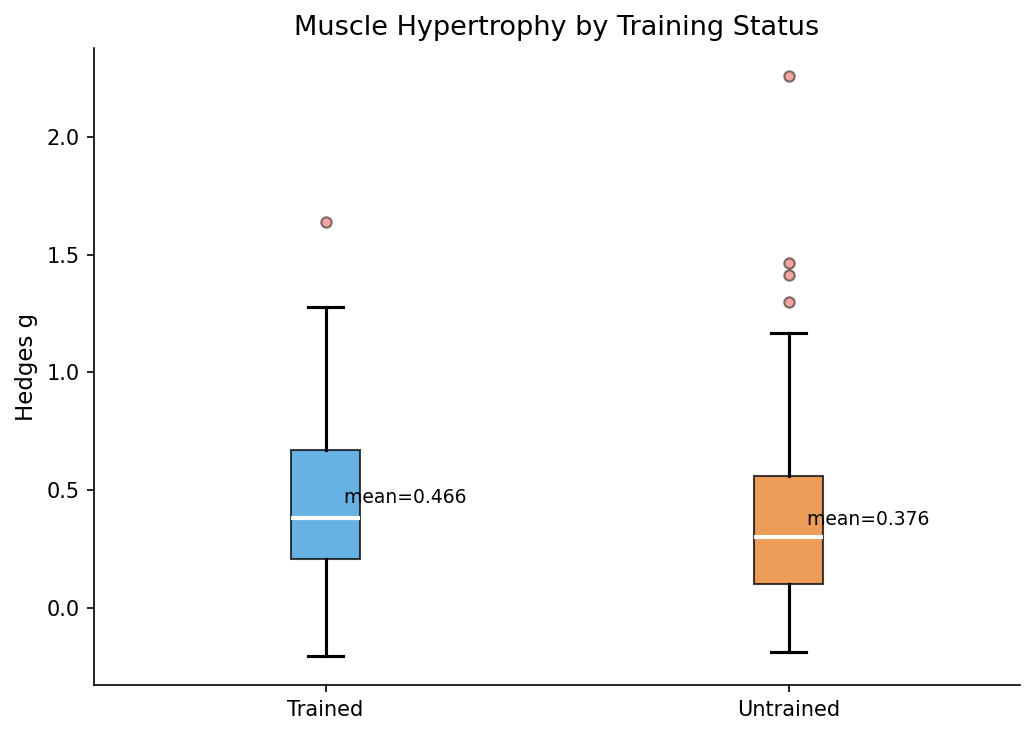

In [8]:
# [MỤC ĐÍCH]: So sánh mức độ thích nghi cơ bắp giữa người đã tập luyện (Trained) và người mới (Untrained).
# [ĐIỂM CHẠM HỌC THUẬT]: Trực quan hóa hiện tượng "Newbie Gains". Nhóm Untrained thường có Mean cao hơn và độ phân tán dữ liệu rộng hơn do trần tiềm năng sinh học còn rất lớn.
fig, ax = plt.subplots(figsize=(7,5))

statuses = ["trained","untrained"]
status_labels = ["Trained","Untrained"]
groups = [df[df["train.status"]==s]["hedges_g"].dropna() for s in statuses]

# [KỸ THUẬT]: Sử dụng Boxplot để quan sát sự khác biệt về trung vị (Median) và các điểm dị biệt (Outliers) giữa hai nhóm trình độ.
bp = ax.boxplot(groups, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2),
                whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markersize=5, alpha=0.5))

for patch, color in zip(bp["boxes"], ["#3498DB","#E67E22"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Hiển thị trực tiếp Mean để làm rõ khoảng cách hiệu ứng (Effect Size gap) giữa hai đối tượng.
means = [g.mean() for g in groups]
for i, m in enumerate(means):
    ax.text(i+1, m, f"   mean={m:.3f}", va="center", fontsize=9)

ax.set_xticklabels(status_labels)
ax.set_ylabel("Hedges g")
ax.set_title("Muscle Hypertrophy by Training Status")
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig3_boxplot_train_status.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Figure 4 — Boxplot Hedges g theo Upper/Lower Body

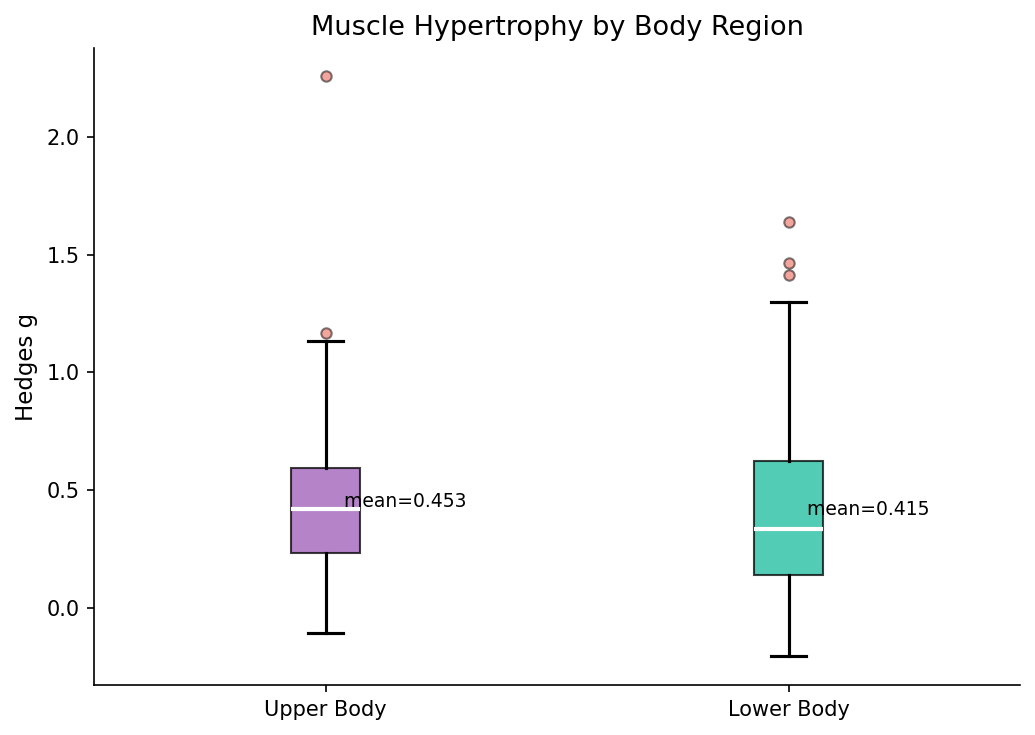

In [9]:
# [MỤC ĐÍCH]: So sánh mức độ phản ứng phì đại giữa nhóm cơ thân trên (Upper) và thân dưới (Lower).
# [ĐIỂM CHẠM HỌC THUẬT]: Kiểm chứng liệu "Vị trí cơ" có phải là biến điều tiết (Moderator) không.
# Sinh lý học: Soi chiếu sự khác biệt về tốc độ tăng trưởng, vốn thường bị ảnh hưởng bởi mật độ thụ thể androgen và loại sợi cơ đặc thù của từng vùng.
fig, ax = plt.subplots(figsize=(7,5))

ul_groups = [
    df[df["upper.lower"]=="upper"]["hedges_g"].dropna(),
    df[df["upper.lower"]=="lower"]["hedges_g"].dropna()
]

# [KỸ THUẬT]: Sử dụng Boxplot để đối chiếu trực quan phân phối Hedges' g, giúp phát hiện sớm các sai lệch hệ thống giữa hai vùng cơ thể.
bp = ax.boxplot(ul_groups, patch_artist=True, notch=False,
                medianprops=dict(color="white", lw=2),
                whiskerprops=dict(lw=1.5), capprops=dict(lw=1.5),
                flierprops=dict(marker="o", markerfacecolor="#E74C3C", markersize=5, alpha=0.5))

for patch, color in zip(bp["boxes"], ["#9B59B6","#1ABC9C"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Annotate means: Hiển thị giá trị trung bình để xác định nhanh vùng cơ nào có xu hướng đáp ứng tập luyện tốt hơn trong tập mẫu.
means = [g.mean() for g in ul_groups]
for i, m in enumerate(means):
    ax.text(i+1, m, f"   mean={m:.3f}", va="center", fontsize=9)

ax.set_xticklabels(["Upper Body","Lower Body"])
ax.set_ylabel("Hedges g")
ax.set_title("Muscle Hypertrophy by Body Region")

plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig4_boxplot_upper_lower.png", dpi=300, bbox_inches="tight")
plt.show()

## 7. Figure 5 — Scatter plot: sets/week vs Hedges g

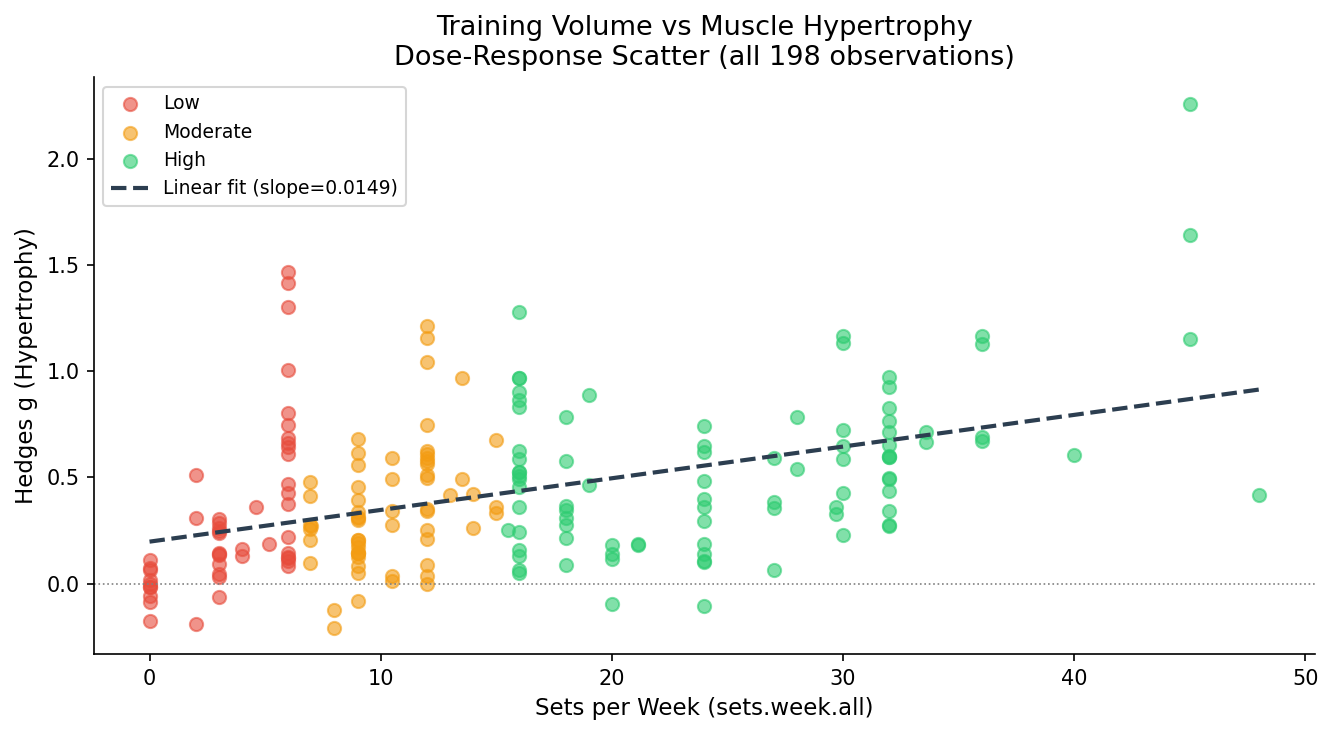

Pearson r = 0.4394, p-value = 0.0000


In [10]:
# [MỤC ĐÍCH]: Trực quan hóa mối tương quan liên tục giữa Tổng số hiệp tập (Sets/Week) và Hiệu quả phì đại.
# [ĐIỂM CHẠM HỌC THUẬT]: Khám phá xu hướng Dose-Response ở cấp độ vi mô. Scatter plot cho phép quan sát sự biến thiên của dữ liệu thực tế xung quanh đường hồi quy, giúp xác định xem việc "tăng thêm volume" có thực sự mang lại kết quả tuyến tính hay không.
from numpy.polynomial import polynomial as P

fig, ax = plt.subplots(figsize=(9,5))

color_map = {"Low":"#E74C3C","Moderate":"#F39C12","High":"#2ECC71"}
for cat in ["Low","Moderate","High"]:
    sub = df[df["volume_category"]==cat]
    ax.scatter(sub["sets.week.all"], sub["hedges_g"],
               color=color_map[cat], alpha=0.6, s=40, label=cat)

# [KỸ THUẬT]: Hồi quy tuyến tính (Linear Regression) để làm nổi bật xu hướng chung của tập dữ liệu.
# Độ dốc (Slope) của đường thẳng này chính là bằng chứng định lượng cho hiệu suất tăng trưởng trên mỗi đơn vị Volume tăng thêm.
x = df["sets.week.all"].values
y = df["hedges_g"].values
mask = ~np.isnan(x) & ~np.isnan(y)
z = np.polyfit(x[mask], y[mask], 1)
p_fn = np.poly1d(z)
x_line = np.linspace(x[mask].min(), x[mask].max(), 100)
ax.plot(x_line, p_fn(x_line), color="#2C3E50", lw=2, ls="--", label=f"Linear fit (slope={z[0]:.4f})")

ax.set_xlabel("Sets per Week (sets.week.all)")
ax.set_ylabel("Hedges g (Hypertrophy)")
ax.set_title("Training Volume vs Muscle Hypertrophy\nDose-Response Scatter (all 198 observations)")
ax.legend(fontsize=9)
ax.axhline(0, color="gray", lw=0.8, ls=":")
plt.tight_layout()
plt.savefig("/content/gdrive/MyDrive/STAT3013/fig5_scatter_volume_hypertrophy.png", dpi=300, bbox_inches="tight")
plt.show()

# [KIỂM ĐỊNH]: Tính toán hệ số tương quan Pearson (r).
# Chỉ số này giúp xác nhận độ chặt chẽ của mối quan hệ giữa Volume và Hypertrophy. p-value < 0.05 sẽ khẳng định mối tương quan này không phải do ngẫu nhiên.
from scipy import stats
r, p_val = stats.pearsonr(x[mask], y[mask])
print(f"Pearson r = {r:.4f}, p-value = {p_val:.4f}")

## 8. Summary output

In [11]:
# [MỤC ĐÍCH]: Xuất bản tóm tắt các thông số thống kê mô tả (Descriptive Statistics) then chốt.
# [KỸ THUẬT]: Đối chiếu Mean và Median của Hedges' g để xác định độ hội tụ của dữ liệu.
# Việc phân tách theo từng nhóm Volume (Low/Moderate/High) giúp định hình nhanh xu hướng Dose-response trước khi đi vào các kiểm định phức tạp.

print("="*55)
print("DESCRIPTIVE STATS SUMMARY")
print("="*55)
print(f"  Total observations:  {len(df)}")
print(f"  hedges_g mean:       {df['hedges_g'].mean():.4f}")
print(f"  hedges_g median:     {df['hedges_g'].median():.4f}")
print(f"  hedges_g SD:         {df['hedges_g'].std():.4f}")
print(f"  hedges_g range:      [{df['hedges_g'].min():.4f}, {df['hedges_g'].max():.4f}]")
print(f"  sets/week mean:      {df['sets.week.all'].mean():.2f}")
print(f"  sets/week range:     [{df['sets.week.all'].min()}, {df['sets.week.all'].max()}]")

print("\n  Volume groups:")
# Vòng lặp duyệt qua các phân đoạn Volume để so sánh hiệu suất (g_mean) tương ứng.
for cat in ["Low","Moderate","High"]:
    sub = df[df["volume_category"]==cat]
    print(f"    {cat:8s}: n={len(sub):3d}, g_mean={sub['hedges_g'].mean():.4f}")

# Danh sách các tệp tin kết quả phục vụ công tác lưu trữ và trích xuất báo cáo đồ án.
print("\nFILES SAVED:")
print("  descriptive_stats.csv")
print("  fig1_hedges_g_distribution.png")
print("  fig2_boxplot_volume_category.png")
print("  fig3_boxplot_train_status.png")
print("  fig4_boxplot_upper_lower.png")
print("  fig5_scatter_volume_hypertrophy.png")

DESCRIPTIVE STATS SUMMARY
  Total observations:  198
  hedges_g mean:       0.4291
  hedges_g median:     0.3603
  hedges_g SD:         0.3698
  hedges_g range:      [-0.2080, 2.2588]
  sets/week mean:      15.50
  sets/week range:     [0.0, 48.0]

  Volume groups:
    Low     : n= 48, g_mean=0.3051
    Moderate: n= 61, g_mean=0.3624
    High    : n= 89, g_mean=0.5416

FILES SAVED:
  descriptive_stats.csv
  fig1_hedges_g_distribution.png
  fig2_boxplot_volume_category.png
  fig3_boxplot_train_status.png
  fig4_boxplot_upper_lower.png
  fig5_scatter_volume_hypertrophy.png
